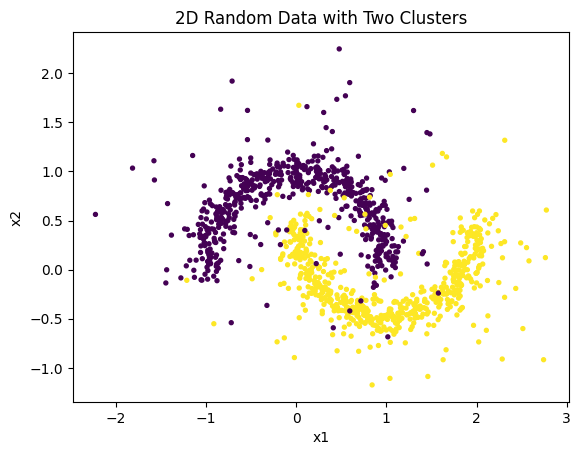

In [33]:
from sklearn.datasets import make_moons
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np

X, y = make_moons(
        n_samples=1000,
        noise=0.1,
        random_state=42
    )
X_noise , y_noise = make_moons(
        n_samples=200,
        noise=0.5,
        random_state=42
    )
X = np.append(X,X_noise,axis=0)
y = np.append(y,y_noise,axis=0)


X_scale = StandardScaler().fit_transform(X)
X_scale

plt.scatter(X[:, 0], X[:, 1], c=y, s=8)
plt.title("2D Random Data with Two Clusters")
plt.xlabel("x1")
plt.ylabel("x2")
plt.show()

In [ ]:
from sklearn.cluster import DBSCAN
import pandas as pd

np.random.RandomState(42)

epsilons = [0.05,0.1,0.15,0.2]
mins = [3,5,10,12]

n_clusters = pd.DataFrame(mins,columns=["min_samples"])
n_noise = pd.DataFrame(mins,columns=["min_samples"])

for ep in epsilons:
    for i, min in enumerate(mins):
        db = DBSCAN(
            eps=ep,
            min_samples=min
        )
        labels = db.fit_predict(X_scale)
        n_clusters.loc[i,f"ep: {ep}"] = len(np.unique(db.labels_[db.labels_ >= 0]))
        n_noise.loc[i,f"ep: {ep}"] = len(db.labels_[db.labels_ < 0])

        plt.scatter(
            X_scale[labels == -1, 0],
            X_scale[labels == -1, 1],
            marker='x',
            label="Noise"
        )

        plt.scatter(
            X_scaled[(labels != -1) & core_mask, 0],
            X_scaled[(labels != -1) & core_mask, 1],
            label="Core points"
        )
        
print("n_clusters"+"-"*50)
print(n_clusters)
print("n_noise---"+"-"*50)
print(n_noise)

n_clusters--------------------------------------------------
   min_samples  ep: 0.05  ep: 0.1  ep: 0.15  ep: 0.2
0            3      49.0      5.0       8.0      4.0
1            5      37.0      1.0       1.0      1.0
2           10      11.0      2.0       1.0      1.0
3           12       6.0      2.0       2.0      1.0
n_noise-----------------------------------------------------
   min_samples  ep: 0.05  ep: 0.1  ep: 0.15  ep: 0.2
0            3     260.0     88.0      52.0     32.0
1            5     443.0    128.0      81.0     55.0
2           10    1038.0    186.0      90.0     67.0
3           12    1123.0    227.0      96.0     68.0


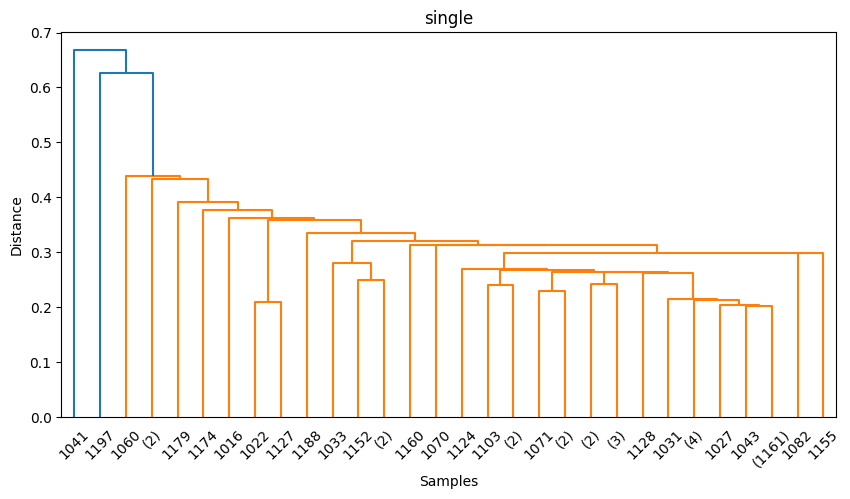

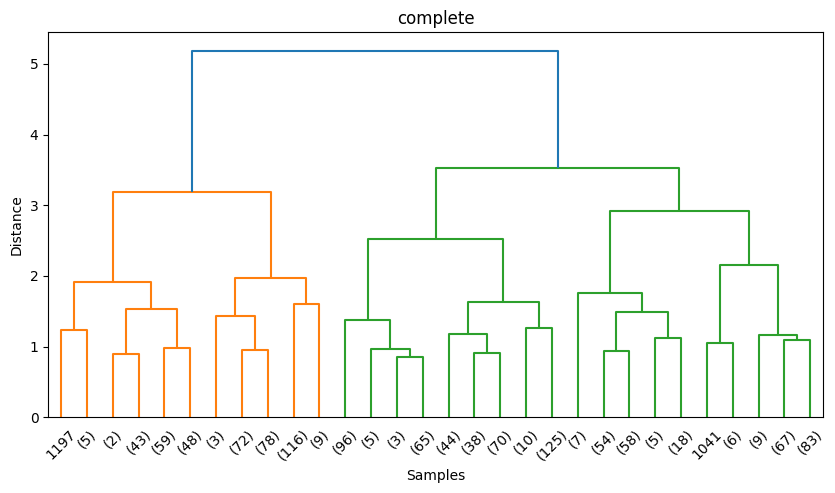

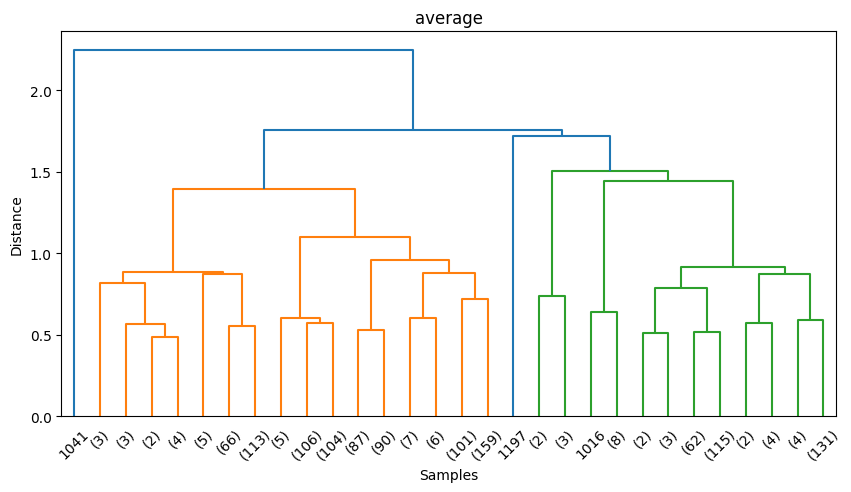

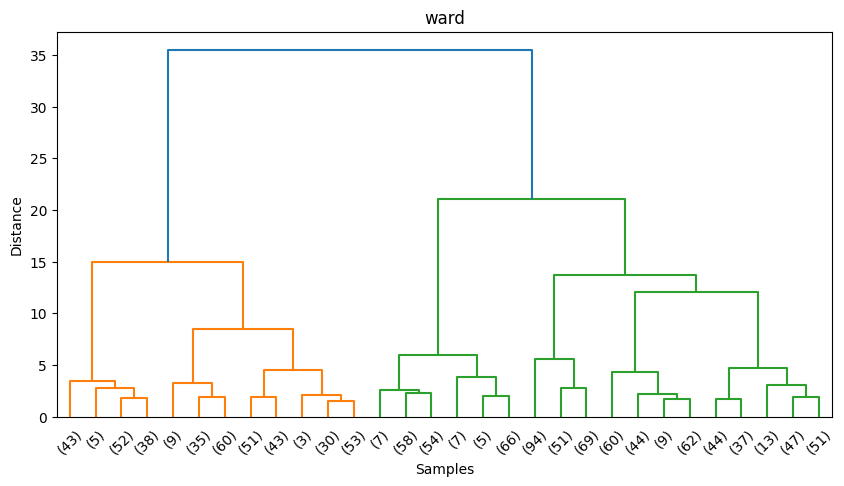

In [ ]:
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

linkages = ['single','complete','average','ward']

for lin in linkages:
    agg = AgglomerativeClustering(
        linkage=lin
    )


    Z = linkage(X, method=lin)

    plt.figure(figsize=(10,5))
    dendrogram(Z,truncate_mode='lastp')
    plt.xlabel("Samples")
    plt.ylabel("Distance")
    plt.title(lin)
    plt.show()


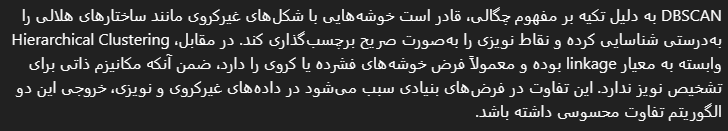

https://chatgpt.com/s/t_6956f0d3bd388191aac1bb96b27d5186